In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

In [2]:
dataset = pd.read_csv(r"C:\Users\Disha\TU Braunschweig\Thesis\Data\Merged Dataset.csv")

In [3]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR)
0,Austria,2011,0.18,631.0,"308,167.0",3.286579,1.6,NaN,17.5,175.00,4.0,16.375,95.00,NaN
1,Austria,2012,0.13,427.0,"316,589.4",2.485676,1.0,1063.0,NaN,NaN,4.0,NaN,95.00,NaN
2,Austria,2013,0.21,656.0,"321,191.7",2.000156,0.4,1173.0,48.2,270.00,8.0,32.900,142.22,30469.93
3,Austria,2014,0.44,1344.0,"330,113.5",1.605812,1.0,1393.0,22.6,240.00,13.0,33.260,155.77,35555.64
4,Austria,2015,0.55,1699.0,"342,083.5",0.896563,0.6,1625.0,47.7,381.25,21.0,56.410,215.22,42052.00


In [4]:
dataset.shape

(378, 14)

In [5]:
# Check structure
dataset.info()

# Basic stats
dataset.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         378 non-null    object 
 1   Year                                            378 non-null    int64  
 2   BEV Percentage (Total Number Of Registrations)  359 non-null    float64
 3   BEV (New Registrations)                         361 non-null    float64
 4   GDP                                             378 non-null    object 
 5   CPI                                             378 non-null    float64
 6   EG                                              378 non-null    float64
 7   Recharging Points                               328 non-null    float64
 8   AC Recharging Speed (km/h)                      324 non-null    float64
 9   DC Recharging Speed (km/h)                 

,count,mean,std,min,25%,50%,75%,max
Year,378.0,2017.500000,4.036472,2011.000000,2014.000000,2017.500000,2021.000000,2024.000000
BEV Percentage (Total Number Of Registrations),359.0,4.014095,7.589880,0.000000,0.125000,0.750000,3.805000,51.720000
BEV (New Registrations),361.0,17072.144044,55647.979509,0.000000,152.000000,1155.000000,7504.000000,520074.000000
CPI,378.0,2.617542,3.284338,-2.096998,0.621773,1.851930,3.288993,19.705046
EG,378.0,1.129101,1.959240,-5.600000,0.125000,1.200000,2.200000,6.900000
Recharging Points,328.0,27643.725610,86340.153928,0.000000,314.500000,1587.000000,10697.250000,675302.000000
AC Recharging Speed (km/h),324.0,44.515749,13.398361,17.500000,40.509586,47.702941,48.864418,70.307692
DC Recharging Speed (km/h),324.0,380.981247,140.783147,175.000000,267.651515,376.375000,467.544255,649.230769
Available,351.0,81.000000,110.403960,4.000000,13.000000,28.000000,97.000000,371.000000
Battery Capacity,324.0,52.278017,18.433308,16.375000,38.615000,57.085723,65.405217,79.230769


# 1. Preprocessing

## A. Convert to similar dataype

In [6]:
# Convert GDP to float
dataset["GDP"] = (
    dataset["GDP"]
    .astype(str)
    .str.replace(",", "")     
    .astype(float)
)

# Verify datatypes 
print(dataset.dtypes)

Country                                            object
Year                                                int64
BEV Percentage (Total Number Of Registrations)    float64
BEV (New Registrations)                           float64
GDP                                               float64
CPI                                               float64
EG                                                float64
Recharging Points                                 float64
AC Recharging Speed (km/h)                        float64
DC Recharging Speed (km/h)                        float64
Available                                         float64
Battery Capacity                                  float64
Real Range                                        float64
Purchase price (EUR)                              float64
dtype: object


## B. Treating null values.

In [7]:
# Finding null values in the dataset
dataset.isnull().sum()

Country                                            0
Year                                               0
BEV Percentage (Total Number Of Registrations)    19
BEV (New Registrations)                           17
GDP                                                0
CPI                                                0
EG                                                 0
Recharging Points                                 50
AC Recharging Speed (km/h)                        54
DC Recharging Speed (km/h)                        54
Available                                         27
Battery Capacity                                  54
Real Range                                        54
Purchase price (EUR)                              81
dtype: int64

**i. Filling BEV (Market Share)**

In [8]:
empty_bev_percentage = dataset[dataset['BEV Percentage (Total Number Of Registrations)'].isnull()][['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)']]
print(empty_bev_percentage)

        Country  Year  BEV Percentage (Total Number Of Registrations)
30     Bulgaria  2013                                             NaN
31     Bulgaria  2014                                             NaN
44      Croatia  2013                                             NaN
58       Cyprus  2013                                             NaN
59       Cyprus  2014                                             NaN
60       Cyprus  2015                                             NaN
212      Latvia  2013                                             NaN
226   Lithuania  2013                                             NaN
227   Lithuania  2014                                             NaN
240  Luxembourg  2013                                             NaN
252       Malta  2011                                             NaN
253       Malta  2012                                             NaN
254       Malta  2013                                             NaN
255       Malta  201

**Reason for log-linear interpolation method:**

1. Preserves non-negativity. 
2. Cosniders multiplicative growth as we can see in certain countries, where the initial years were 0 and then a sudden rise in the numbers. In other words, it gives us a more realistic numbers than just jumping to a higher number. 

In [9]:
# Replace the null values with the log-linear interpolation method
def log_linear_fill(series):
    z = np.log1p(series)
    z_interp = z.interpolate(method='linear', limit_direction='both')
    return np.expm1(z_interp)

dataset['BEV Percentage (Total Number Of Registrations)'] = dataset.groupby('Country')['BEV Percentage (Total Number Of Registrations)'].transform(log_linear_fill)

In [10]:
# Verification
print(dataset.loc[dataset['Country'] == 'Slovenia', ['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)']])

      Country  Year  BEV Percentage (Total Number Of Registrations)
336  Slovenia  2011                                        0.020000
337  Slovenia  2012                                        0.030000
338  Slovenia  2013                                        0.034988
339  Slovenia  2014                                        0.040000
340  Slovenia  2015                                        0.150000
341  Slovenia  2016                                        0.230000
342  Slovenia  2017                                        0.460000
343  Slovenia  2018                                        0.640000
344  Slovenia  2019                                        0.800000
345  Slovenia  2020                                        3.120000
346  Slovenia  2021                                        3.130000
347  Slovenia  2022                                        5.000000
348  Slovenia  2023                                        8.860000
349  Slovenia  2024                             

**ii. Filling BEV (New Registrations)**

In [11]:
empty_bev_newReg = dataset[dataset['BEV (New Registrations)'].isnull()][['Country', 'Year', 'BEV (New Registrations)']]
print(empty_bev_newReg)

        Country  Year  BEV (New Registrations)
30     Bulgaria  2013                      NaN
31     Bulgaria  2014                      NaN
44      Croatia  2013                      NaN
58       Cyprus  2013                      NaN
59       Cyprus  2014                      NaN
60       Cyprus  2015                      NaN
212      Latvia  2013                      NaN
226   Lithuania  2013                      NaN
227   Lithuania  2014                      NaN
240  Luxembourg  2013                      NaN
254       Malta  2013                      NaN
255       Malta  2014                      NaN
256       Malta  2015                      NaN
257       Malta  2016                      NaN
311     Romania  2014                      NaN
324    Slovakia  2013                      NaN
338    Slovenia  2013                      NaN


In [12]:
# Replace the null values with the log-linear interpolation method
def log_linear_fill(series):
    z = np.log1p(series)
    z_interp = z.interpolate(method='linear', limit_direction='both')
    return np.expm1(z_interp)

dataset['BEV (New Registrations)'] = dataset.groupby('Country')['BEV (New Registrations)'].transform(log_linear_fill)

In [13]:
# Verification
print(dataset.loc[dataset['Country'] == 'Slovenia', ['Country', 'Year', 'BEV (New Registrations)']])

      Country  Year  BEV (New Registrations)
336  Slovenia  2011                 12.00000
337  Slovenia  2012                 17.00000
338  Slovenia  2013                 19.34699
339  Slovenia  2014                 22.00000
340  Slovenia  2015                 93.00000
341  Slovenia  2016                152.00000
342  Slovenia  2017                336.00000
343  Slovenia  2018                480.00000
344  Slovenia  2019                579.00000
345  Slovenia  2020               1667.00000
346  Slovenia  2021               1688.00000
347  Slovenia  2022               2319.00000
348  Slovenia  2023               4338.00000
349  Slovenia  2024               3148.00000


**iii. Filling Recharging Points**

In [14]:
empty_recharging = dataset[dataset['Recharging Points'].isnull()][['Country', 'Year', 'Recharging Points']]
print(empty_recharging)

            Country  Year  Recharging Points
0           Austria  2011                NaN
14          Belgium  2011                NaN
15          Belgium  2012                NaN
28         Bulgaria  2011                NaN
29         Bulgaria  2012                NaN
30         Bulgaria  2013                NaN
31         Bulgaria  2014                NaN
42          Croatia  2011                NaN
43          Croatia  2012                NaN
44          Croatia  2013                NaN
45          Croatia  2014                NaN
56           Cyprus  2011                NaN
57           Cyprus  2012                NaN
58           Cyprus  2013                NaN
59           Cyprus  2014                NaN
60           Cyprus  2015                NaN
70   Czech Republic  2011                NaN
84          Denmark  2011                NaN
98          Estonia  2011                NaN
112         Finland  2011                NaN
113         Finland  2012                NaN
126       

In [15]:
# Replace zeros with NaN
dataset["Recharging Points"].replace(0, np.nan, inplace=True)

def backward_extrapolate(group):
    group = group.sort_values("Year").reset_index(drop=True)
    
    # Find first observed value
    first_idx = group["Recharging Points"].first_valid_index()
    
    if first_idx is None:
        # All years missing, fill with 1
        group["Recharging Points"] = 1
        return group

    # Compute slope if possible (log-linear)
    next_idx = first_idx + 1
    if next_idx < len(group) and not np.isnan(group.loc[next_idx, "Recharging Points"]):
        slope = np.log(group.loc[next_idx, "Recharging Points"]) - np.log(group.loc[first_idx, "Recharging Points"])
    else:
        slope = 0.3  # default slope if only one observed value

    # Backward fill only initial NaNs
    for i in range(first_idx - 1, -1, -1):
        group.loc[i, "Recharging Points"] = np.exp(
            np.log(group.loc[i+1, "Recharging Points"]) - slope
        )
    
    return group

# Apply to each country
dataset = dataset.groupby("Country", group_keys=False).apply(backward_extrapolate)

# Fill any remaining NaNs with 1 (safety net)
dataset["Recharging Points"].fillna(1, inplace=True)

# Round and convert to int
dataset["Recharging Points"] = dataset["Recharging Points"].round(0).astype(int)

In [16]:
# Verification
print(dataset.loc[dataset['Country'] == 'Lithuania', ['Country', 'Year', 'Recharging Points']])

      Country  Year  Recharging Points
0   Lithuania  2011                  2
1   Lithuania  2012                  3
2   Lithuania  2013                  6
3   Lithuania  2014                 10
4   Lithuania  2015                 18
5   Lithuania  2016                 26
6   Lithuania  2017                102
7   Lithuania  2018                153
8   Lithuania  2019                146
9   Lithuania  2020                468
10  Lithuania  2021                503
11  Lithuania  2022               1066
12  Lithuania  2023               3837
13  Lithuania  2024               9864


**iv. Filling AC and DC**

In [17]:
empty_ac = dataset[dataset['AC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'AC Recharging Speed (km/h)']]
print(empty_ac)

           Country  Year  AC Recharging Speed (km/h)
1          Austria  2012                         NaN
13         Austria  2024                         NaN
1          Belgium  2012                         NaN
13         Belgium  2024                         NaN
1         Bulgaria  2012                         NaN
13        Bulgaria  2024                         NaN
1          Croatia  2012                         NaN
13         Croatia  2024                         NaN
1           Cyprus  2012                         NaN
13          Cyprus  2024                         NaN
1   Czech Republic  2012                         NaN
13  Czech Republic  2024                         NaN
1          Denmark  2012                         NaN
13         Denmark  2024                         NaN
1          Estonia  2012                         NaN
13         Estonia  2024                         NaN
1          Finland  2012                         NaN
13         Finland  2024                      

In [18]:
empty_dc = dataset[dataset['DC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'DC Recharging Speed (km/h)']]
print(empty_dc)

           Country  Year  DC Recharging Speed (km/h)
1          Austria  2012                         NaN
13         Austria  2024                         NaN
1          Belgium  2012                         NaN
13         Belgium  2024                         NaN
1         Bulgaria  2012                         NaN
13        Bulgaria  2024                         NaN
1          Croatia  2012                         NaN
13         Croatia  2024                         NaN
1           Cyprus  2012                         NaN
13          Cyprus  2024                         NaN
1   Czech Republic  2012                         NaN
13  Czech Republic  2024                         NaN
1          Denmark  2012                         NaN
13         Denmark  2024                         NaN
1          Estonia  2012                         NaN
13         Estonia  2024                         NaN
1          Finland  2012                         NaN
13         Finland  2024                      

In [19]:
# Function for log-linear interpolation for year 2012
def log_linear_interpolation(series):

    # Replace zeros with a small value to avoid log(0)
    series = series.replace(0, np.nan)
    
    # Log-transform
    z = np.log1p(series)
    
    # Linear interpolation in log space
    z_interp = z.interpolate(method='linear', limit_direction='both')
    
    # Inverse transform to original scale
    return np.expm1(z_interp)

# Function for average compound annual growth rate (CAGR-based extrapolation) for year 2024 
def cagr_extrapolation(series, years=3):

    valid = series.dropna()
    if len(valid) >= years + 1:
        
        # Compute CAGR over last 'years' observed
        g = (valid.iloc[-1] / valid.iloc[-(years+1)]) ** (1/years) - 1
        
        # Extrapolate last value if missing or to extend trend
        if pd.isna(series.iloc[-1]) or series.iloc[-1] == valid.iloc[-1]:
            series.iloc[-1] = valid.iloc[-1] * (1 + g)
    return series

# Apply both methods by country depending on the year
for col in ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)']:
    # Step 1: Log-linear interpolation for internal missing years
    dataset[col] = dataset.groupby('Country')[col].transform(log_linear_interpolation)
    
    # Step 2: CAGR-based extrapolation for the last year (2024)
    dataset[col] = dataset.groupby('Country')[col].transform(cagr_extrapolation)

In [20]:
# Verification
print(dataset.loc[dataset['Country'] == 'Estonia', ['Country', 'Year', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)']])

    Country  Year  AC Recharging Speed (km/h)  DC Recharging Speed (km/h)
0   Estonia  2011                   17.500000                  175.000000
1   Estonia  2012                   29.169521                  217.394139
2   Estonia  2013                   48.200000                  270.000000
3   Estonia  2014                   22.600000                  240.000000
4   Estonia  2015                   47.700000                  381.250000
5   Estonia  2016                   44.850000                  371.500000
6   Estonia  2017                   47.705882                  267.272727
7   Estonia  2018                   48.714286                  267.777778
8   Estonia  2019                   57.066667                  458.928571
9   Estonia  2020                   39.325301                  403.164557
10  Estonia  2021                   40.904348                  493.391304
11  Estonia  2022                   49.314815                  594.259259
12  Estonia  2023                   70

**Reason for using two different filling methods:**

1. For year 2012, log-linear interpolation was applied to capture the multiplicative growth trend between two observed points.

2. For year 2024, extrapolation using the average compound annual growth rate (CAGR) from the last 3 observed years was applied.

This hybrid approach ensures that interpolated values reflect local trends, while extrapolated terminal values project realistic growth.

Please refer paper mentioned in BEV and "Interpolation in Time Series_An Introductive Overview of Existing Methods, Their Performance Criteria and Uncertainty Assessment".

**v. Filling Available Models**

In [21]:
empty_available = dataset[dataset['Available'].isnull()][['Country', 'Year', 'Available']]
print(empty_available)

           Country  Year  Available
13         Austria  2024        NaN
13         Belgium  2024        NaN
13        Bulgaria  2024        NaN
13         Croatia  2024        NaN
13          Cyprus  2024        NaN
13  Czech Republic  2024        NaN
13         Denmark  2024        NaN
13         Estonia  2024        NaN
13         Finland  2024        NaN
13          France  2024        NaN
13         Germany  2024        NaN
13          Greece  2024        NaN
13         Hungary  2024        NaN
13         Ireland  2024        NaN
13           Italy  2024        NaN
13          Latvia  2024        NaN
13       Lithuania  2024        NaN
13      Luxembourg  2024        NaN
13           Malta  2024        NaN
13     Netherlands  2024        NaN
13          Poland  2024        NaN
13        Portugal  2024        NaN
13         Romania  2024        NaN
13        Slovakia  2024        NaN
13        Slovenia  2024        NaN
13           Spain  2024        NaN
13          Sweden  2024    

In [22]:
# Function for average compound annual growth rate (CAGR-based extrapolation) for year 2024 
def cagr_extrapolation(series, years=3):

    valid = series.dropna()
    if len(valid) >= years + 1:
        
        # Compute CAGR over last 'years' observed
        g = (valid.iloc[-1] / valid.iloc[-(years+1)]) ** (1/years) - 1
        
        # Extrapolate last value if missing or to extend trend
        if pd.isna(series.iloc[-1]) or series.iloc[-1] == valid.iloc[-1]:
            series.iloc[-1] = valid.iloc[-1] * (1 + g)
    return series

# Apply both methods by country depending on the year
for col in ['Available']:
   
    # CAGR-based extrapolation for the last year (2024)
    dataset[col] = dataset.groupby('Country')[col].transform(cagr_extrapolation)

In [23]:
# Verification
print(dataset.loc[dataset['Country'] == 'Lithuania', ['Country', 'Year', 'Available']])

      Country  Year   Available
0   Lithuania  2011    4.000000
1   Lithuania  2012    4.000000
2   Lithuania  2013    8.000000
3   Lithuania  2014   13.000000
4   Lithuania  2015   21.000000
5   Lithuania  2016   23.000000
6   Lithuania  2017   28.000000
7   Lithuania  2018   29.000000
8   Lithuania  2019   34.000000
9   Lithuania  2020   97.000000
10  Lithuania  2021  168.000000
11  Lithuania  2022  253.000000
12  Lithuania  2023  371.000000
13  Lithuania  2024  580.195872


**vi. Filling Battery Capacity**

In [24]:
empty_battery_capacity = dataset[dataset['Battery Capacity'].isnull()][['Country', 'Year', 'Battery Capacity']]
print(empty_battery_capacity)

           Country  Year  Battery Capacity
1          Austria  2012               NaN
13         Austria  2024               NaN
1          Belgium  2012               NaN
13         Belgium  2024               NaN
1         Bulgaria  2012               NaN
13        Bulgaria  2024               NaN
1          Croatia  2012               NaN
13         Croatia  2024               NaN
1           Cyprus  2012               NaN
13          Cyprus  2024               NaN
1   Czech Republic  2012               NaN
13  Czech Republic  2024               NaN
1          Denmark  2012               NaN
13         Denmark  2024               NaN
1          Estonia  2012               NaN
13         Estonia  2024               NaN
1          Finland  2012               NaN
13         Finland  2024               NaN
1           France  2012               NaN
13          France  2024               NaN
1          Germany  2012               NaN
13         Germany  2024               NaN
1          

In [25]:
# Function for log-linear interpolation for year 2012
def log_linear_interpolation(series):

    # Replace zeros with a small value to avoid log(0)
    series = series.replace(0, np.nan)
    
    # Log-transform
    z = np.log1p(series)
    
    # Linear interpolation in log space
    z_interp = z.interpolate(method='linear', limit_direction='both')
    
    # Inverse transform to original scale
    return np.expm1(z_interp)

# Function for average compound annual growth rate (CAGR-based extrapolation) for year 2024 
def cagr_extrapolation(series, years=3):

    valid = series.dropna()
    if len(valid) >= years + 1:
        
        # Compute CAGR over last 'years' observed
        g = (valid.iloc[-1] / valid.iloc[-(years+1)]) ** (1/years) - 1
        
        # Extrapolate last value if missing or to extend trend
        if pd.isna(series.iloc[-1]) or series.iloc[-1] == valid.iloc[-1]:
            series.iloc[-1] = valid.iloc[-1] * (1 + g)
    return series

# Apply both methods by country depending on the year
for col in ['Battery Capacity']:
    # Step 1: Log-linear interpolation for internal missing years
    dataset[col] = dataset.groupby('Country')[col].transform(log_linear_interpolation)
    
    # Step 2: CAGR-based extrapolation for the last year (2024)
    dataset[col] = dataset.groupby('Country')[col].transform(cagr_extrapolation)

In [26]:
# Verification
print(dataset.loc[dataset['Country'] == 'Bulgaria', ['Country', 'Year', 'Battery Capacity']])

     Country  Year  Battery Capacity
0   Bulgaria  2011         16.375000
1   Bulgaria  2012         23.269580
2   Bulgaria  2013         32.900000
3   Bulgaria  2014         33.260000
4   Bulgaria  2015         56.410000
5   Bulgaria  2016         62.485000
6   Bulgaria  2017         40.400000
7   Bulgaria  2018         41.200000
8   Bulgaria  2019         69.480000
9   Bulgaria  2020         57.761446
10  Bulgaria  2021         64.046957
11  Bulgaria  2022         73.787037
12  Bulgaria  2023         79.230769
13  Bulgaria  2024         85.053528


**vii. Filling Real Range of BEV**

In [27]:
empty_real_range = dataset[dataset['Real Range'].isnull()][['Country', 'Year', 'Real Range']]
print(empty_real_range)

           Country  Year  Real Range
12         Austria  2023         NaN
13         Austria  2024         NaN
12         Belgium  2023         NaN
13         Belgium  2024         NaN
12        Bulgaria  2023         NaN
13        Bulgaria  2024         NaN
12         Croatia  2023         NaN
13         Croatia  2024         NaN
12          Cyprus  2023         NaN
13          Cyprus  2024         NaN
12  Czech Republic  2023         NaN
13  Czech Republic  2024         NaN
12         Denmark  2023         NaN
13         Denmark  2024         NaN
12         Estonia  2023         NaN
13         Estonia  2024         NaN
12         Finland  2023         NaN
13         Finland  2024         NaN
12          France  2023         NaN
13          France  2024         NaN
12         Germany  2023         NaN
13         Germany  2024         NaN
12          Greece  2023         NaN
13          Greece  2024         NaN
12         Hungary  2023         NaN
13         Hungary  2024         NaN
1

In [28]:
# Function for average compound annual growth rate (CAGR-based extrapolation) for year 2023 and 2024
def extrapolate_real_range(series, years_to_use=3):

    valid = series.dropna()
    n = years_to_use
    if len(valid) >= n + 1:
        
        # Calculate CAGR from last 3 observed years
        g = (valid.iloc[-1] / valid.iloc[-(n+1)]) ** (1/n) - 1
        
        # Fill missing values year by year
        for i in range(len(series)):
            if pd.isna(series.iloc[i]):
                series.iloc[i] = valid.iloc[-1] * (1 + g)
                # Update valid.iloc[-1] to the newly filled value for next year
                valid = pd.concat([valid, pd.Series(series.iloc[i])], ignore_index=True)
    return series

# Apply for all countries
dataset['Real Range'] = dataset.groupby('Country')['Real Range'].transform(extrapolate_real_range)

In [29]:
# Verification
print(dataset.loc[dataset['Country'] == 'Bulgaria', ['Country', 'Year', 'Real Range']])

     Country  Year  Real Range
0   Bulgaria  2011   95.000000
1   Bulgaria  2012   95.000000
2   Bulgaria  2013  142.220000
3   Bulgaria  2014  155.770000
4   Bulgaria  2015  215.220000
5   Bulgaria  2016  269.270000
6   Bulgaria  2017  221.750000
7   Bulgaria  2018  216.550000
8   Bulgaria  2019  300.680000
9   Bulgaria  2020  286.200000
10  Bulgaria  2021  308.730000
11  Bulgaria  2022  345.440000
12  Bulgaria  2023  361.794521
13  Bulgaria  2024  378.923332


**viii. Filling Purchase Price**

In [30]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
empty_price = dataset[dataset['Purchase price (EUR)'].isnull()][['Country', 'Year', 'Purchase price (EUR)']]
print(empty_price)

           Country  Year  Purchase price (EUR)
0          Austria  2011                   NaN
1          Austria  2012                   NaN
13         Austria  2024                   NaN
0          Belgium  2011                   NaN
1          Belgium  2012                   NaN
13         Belgium  2024                   NaN
0         Bulgaria  2011                   NaN
1         Bulgaria  2012                   NaN
13        Bulgaria  2024                   NaN
0          Croatia  2011                   NaN
1          Croatia  2012                   NaN
13         Croatia  2024                   NaN
0           Cyprus  2011                   NaN
1           Cyprus  2012                   NaN
13          Cyprus  2024                   NaN
0   Czech Republic  2011                   NaN
1   Czech Republic  2012                   NaN
13  Czech Republic  2024                   NaN
0          Denmark  2011                   NaN
1          Denmark  2012                   NaN
13         De

In [31]:
# Log-linear transformation for years 2011-2012 and 2024.
def log_linear_fill(series):

    s = series.copy()
    # log1p to avoid log(0) issues
    s_log = np.log1p(s)
    s_interp = s_log.interpolate(method='linear', limit_direction='both')
    return np.expm1(s_interp)

# Apply per country
dataset['Purchase price (EUR)'] = dataset.groupby('Country')['Purchase price (EUR)'].transform(log_linear_fill)

In [32]:
# Verification
print(dataset.loc[dataset['Country'] == 'Czech Republic', ['Country', 'Year', 'Purchase price (EUR)']])

           Country  Year  Purchase price (EUR)
0   Czech Republic  2011              30469.93
1   Czech Republic  2012              30469.93
2   Czech Republic  2013              30469.93
3   Czech Republic  2014              35555.64
4   Czech Republic  2015              42052.00
5   Czech Republic  2016              39789.11
6   Czech Republic  2017              44717.86
7   Czech Republic  2018              46225.88
8   Czech Republic  2019              42237.97
9   Czech Republic  2020              38311.38
10  Czech Republic  2021              40745.01
11  Czech Republic  2022              43874.27
12  Czech Republic  2023              45999.05
13  Czech Republic  2024              45999.05


**Reason for using log-linear trasnformation and not CAGR Extrapolation:**

1. Nature of the Variable
- Purchase prices usually grow **exponentially over time** due to inflation and technology improvements. However, its seen that there is a linear trend in the years from 2013 to 2023.

2. Why Not Simple Extrapolation?
- Extrapolation (using CAGR) requires at least **two known points** at the edges of the missing data.  
- All 27 countries had missing values **at the start**, so CAGR could not be computed reliably.  
- Manual extrapolation is **fragile**, can cause errors, and may produce unrealistic values if the series is volatile.  

3. Why Log-Linear Interpolation?

- Many variables (like BEV sales or purchase price) grow **exponentially over time**:
- Taking the **natural log** transforms the series to linear form:
- On the **log scale**, missing values can be filled using **linear interpolation**:
- After filling, convert back to the original scale using **exponentiation**:
- Advantages:
  1. Fills **all gaps** (start, middle, end) in a consistent trend.
  2. Avoids **manual index calculations**, preventing errors.
  3. Automatically adapts to **exponential growth patterns**.

For reference, please refer **"Statistical Analysis with Missing Data"**.

# 2. Exploratory Data Analysis (EDA)

In [33]:
# Seperating the variables based on whether they are average or unique for each country and year
country_vars = ['BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points']
eu_avg_vars = ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
               'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']

## A. Descriptive analysis

In [34]:
print("Country Level Stats:")
dataset[country_vars].describe()

Country Level Stats:


,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points
count,378.000000,378.000000,3.780000e+02,378.000000,378.000000,378.000000
mean,3.824940,16304.921149,2.747938e+06,2.617542,1.129101,24008.698413
std,7.442088,54493.959794,9.282203e+06,3.284338,1.959240,80949.805011
min,0.000000,0.000000,7.032800e+03,-2.096998,-5.600000,0.000000
25%,0.110000,92.250000,5.720340e+04,0.621773,0.125000,154.750000
50%,0.620000,921.500000,3.082665e+05,1.851930,1.200000,1064.500000
75%,3.555000,6745.000000,1.861603e+06,3.288993,2.200000,7422.750000
max,51.720000,520074.000000,8.144766e+07,19.705046,6.900000,675302.000000


In [35]:
print("Average Level Stats:")
dataset[eu_avg_vars].describe()

Average Level Stats:


,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR)
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,46.255590,392.900262,116.656848,52.547094,242.324847,39779.786429
std,16.749137,163.020640,166.997790,20.694079,91.450593,5690.949944
min,17.500000,175.000000,4.000000,16.375000,95.000000,30469.930000
25%,39.325301,267.272727,13.000000,33.260000,155.770000,35555.640000
50%,47.702941,376.375000,28.500000,57.085723,245.510000,41398.505000
75%,49.314815,493.391304,168.000000,69.480000,308.730000,44717.860000
max,84.219754,711.434566,580.195872,85.053528,378.923332,46225.880000


## B. Temporal Analysis (2011-2024)

In [36]:
# Aggregate country-specific metrics grouped by "Year"
# We take sum for discrete variables like "Total BEV New Registrations" & "Total charging Points"
# because they accumlate across the countries.
# We calcualte the mean of countinuous variables and BEV Percentage (Total Number Of Registrations) to capture the average economic conditions in the EU. 
eu_agg_data = dataset.groupby('Year').agg(
    Avg_BEVs_percentage=('BEV Percentage (Total Number Of Registrations)', 'mean'),
    Total_BEVs_newReg=('BEV (New Registrations)', 'sum'),
    Total_Charging_Points=('Recharging Points', 'sum'),
    Avg_GDP_per_Capita=('GDP', 'mean'), 
    Avg_CPI=('CPI', 'mean'),
    Avg_EG=('EG', 'mean')
).reset_index()

# Extract unique EU average metrics to describe BEV technology improvements and trends over years 
tech_agg_data = dataset[['Year',
    'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
    'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']
].drop_duplicates().reset_index(drop=True) # drop the duplicates because we have the same value across all the EU countries for each year.

To check the relation between the #BEV Market Share and #Recharging Points 

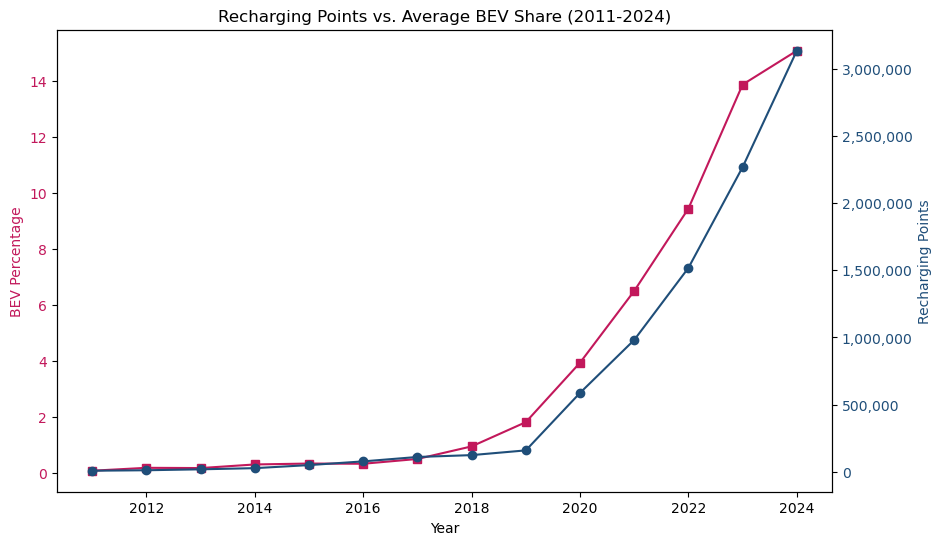

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Registration Count on the left axis
ax1.set_xlabel('Year')
ax1.set_ylabel('BEV Percentage', color='#C2185B')
ax1.plot(eu_agg_data['Year'], eu_agg_data['Avg_BEVs_percentage'], marker='s', color='#C2185B', label='Market Share')
ax1.tick_params(axis='y', labelcolor='#C2185B')

# Create a twin axis for the Recharging Points
ax2 = ax1.twinx() 
ax2.set_ylabel('Recharging Points', color='#1f4e79')
ax2.plot(eu_agg_data['Year'], eu_agg_data['Total_Charging_Points'], marker='o', color='#1f4e79', label='Recharging Points')
ax2.tick_params(axis='y', labelcolor='#1f4e79')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title('Recharging Points vs. Average BEV Share (2011-2024)')
plt.savefig("Recharging Points vs Average BEV Share.pdf", format="pdf", bbox_inches="tight")
plt.show()

To check the average of the influencing factors

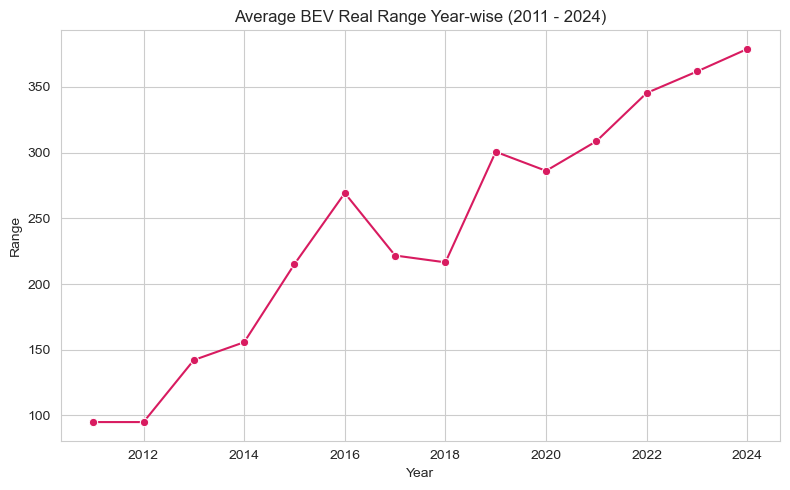

In [38]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Real Range', marker='o', color='#D81B60')

plt.title('Average BEV Real Range Year-wise (2011 - 2024)')
plt.xlabel('Year')
plt.ylabel('Range')

plt.tight_layout()
plt.savefig("Average Real Range.pdf", format="pdf", bbox_inches="tight")
plt.show()

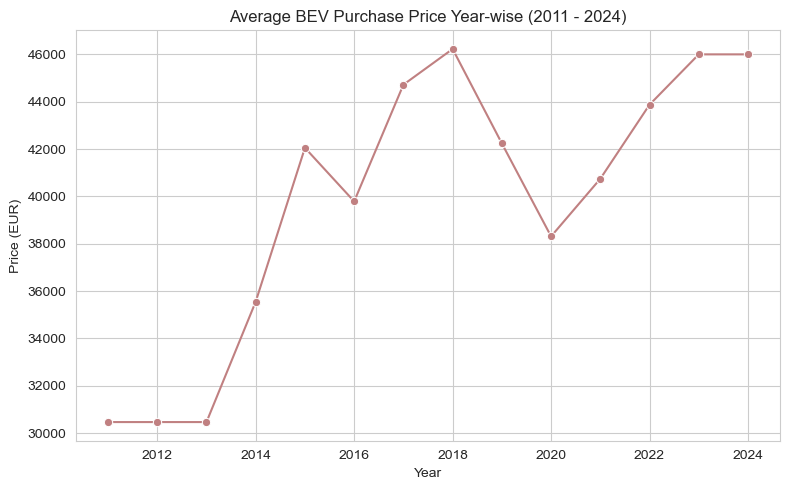

In [39]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Purchase price (EUR)', marker='o', color='#C08081')

plt.title('Average BEV Purchase Price Year-wise (2011 - 2024)')
plt.xlabel('Year')
plt.ylabel('Price (EUR)')

plt.tight_layout()
plt.savefig("Average BEV Purchase Price.pdf", format="pdf", bbox_inches="tight")
plt.show()

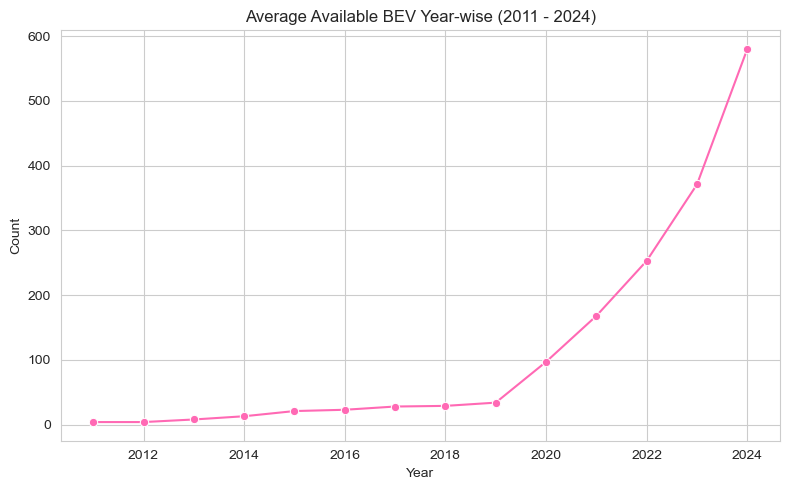

In [40]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Available', marker='o', color='#FF69B4')

plt.title('Average Available BEV Year-wise (2011 - 2024)')
plt.xlabel('Year')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig("Average Available BEV Models.pdf", format="pdf", bbox_inches="tight")
plt.show()

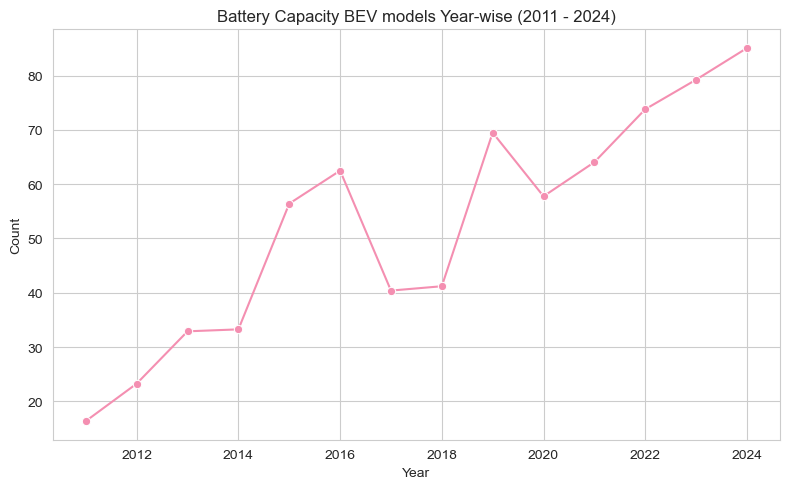

In [41]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Battery Capacity', marker='o', color='#F48FB1')

plt.title('Battery Capacity BEV models Year-wise (2011 - 2024)')
plt.xlabel('Year')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Data Transformations

1. Applying Logarithimic Transformation to the dataset only if - skewness is > +1 or < -1 
2. Moderately skewed if - ±0.5 < skewness < ±1
3. Symeytric if - -0.5 < skewness < +0.5

**1. Applying Log transformation for highly skewed columns**

**Literature:** HANDBOOK OF BIOLOGICAL STATISTICS.

In [42]:
# Checking country level skewness
numeric_cols = ['BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'Recharging Points', 'GDP', 'CPI', 'EG']
for col in numeric_cols:
    print(f"{col} skew before transformation: {dataset[col].skew():.2f}")

BEV Percentage (Total Number Of Registrations) skew before transformation: 3.06
BEV (New Registrations) skew before transformation: 6.08
Recharging Points skew before transformation: 5.29
GDP skew before transformation: 5.76
CPI skew before transformation: 2.34
EG skew before transformation: -0.09


In [43]:
# Checking if there is any skewness
average_cols = ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
                'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']

# Drop duplicates across countries — keep unique yearly values
average_data = dataset[['Year'] + average_cols].drop_duplicates(subset=['Year'])

# Print results
average_data[average_cols].skew()

AC Recharging Speed (km/h)    0.471165
DC Recharging Speed (km/h)    0.623294
Available                     1.901217
Battery Capacity             -0.181487
Real Range                   -0.226282
Purchase price (EUR)         -0.670909
dtype: float64

In [44]:
# Country level log transformation
countrylevel_cols = ['BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'Recharging Points', 'GDP', 'CPI']

# Merge in the dataset
for col in countrylevel_cols:
    dataset[f'Log_{col}'] = np.log1p(dataset[col])
    
# Verification
for col in countrylevel_cols:
    print(f"{col} skew before log transform: {dataset[col].skew():.2f}")
    print(f"Log_{col} skew after log1p transform: {dataset[f'Log_{col}'].skew():.2f}\n")

BEV Percentage (Total Number Of Registrations) skew before log transform: 3.06
Log_BEV Percentage (Total Number Of Registrations) skew after log1p transform: 1.10

BEV (New Registrations) skew before log transform: 6.08
Log_BEV (New Registrations) skew after log1p transform: -0.19

Recharging Points skew before log transform: 5.29
Log_Recharging Points skew after log1p transform: -0.21

GDP skew before log transform: 5.76
Log_GDP skew after log1p transform: 0.29

CPI skew before log transform: 2.34
Log_CPI skew after log1p transform: -0.58



C:\Users\Disha\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [45]:
# Average level log transformations
average_cols = [
    'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
    'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)'
]
average_data = dataset[['Year'] + average_cols].drop_duplicates(subset=['Year']).copy()

# Apply log transform for right-skewed features
average_data['Log_Available'] = np.log1p(average_data['Available'])
average_data['Log_DC Recharging Speed (km/h)'] = np.log1p(average_data['DC Recharging Speed (km/h)'])

# Verification
print("Before log transform (Available):", average_data['Available'].skew())
print("After log transform (Log_Available):", average_data['Log_Available'].skew())
print("Before log transform (DC Recharging Speed (km/h)):", average_data['DC Recharging Speed (km/h)'].skew())
print("After log transform (Log_DC Recharging Speed (km/h)):", average_data['Log_DC Recharging Speed (km/h)'].skew())

Before log transform (Available): 1.901217099345369
After log transform (Log_Available): 0.333133087259208
Before log transform (DC Recharging Speed (km/h)): 0.6232940250400307
After log transform (Log_DC Recharging Speed (km/h)): 0.04354490810882036


In [46]:
# Merge back to the main dataset
dataset = dataset.merge(
    average_data[['Year', 'Log_Available', 'Log_DC Recharging Speed (km/h)']],
    on='Year',
    how='left'
)

dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,4.0,16.37500,95.00,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,4.0,23.26958,95.00,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,8.0,32.90000,142.22,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,13.0,33.26000,155.77,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,21.0,56.41000,215.22,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075


**2. Applying Yeo-Johnson Transform for moderately left-skewed feature**

**Explanation:** We are aware that "Purchase Price (EUR)" is left skewed.
Log transform is made for right-skewed data; when I try to use log on left-skewed data (even with reflection), it stretches the tail too much, makes skew worse instead of better, which is leading to overkill the data (skew goes from –0.67 to –2.22).

Yeo–Johnson is a smart, flexible transform that automatically decides: How much to stretch the low values and compress the high.  values.

**Literature:** A new family of power transformations to improve normality or symmetry.

In [47]:
# Initialize Yeo-Johnson transformer
pt = PowerTransformer(method='yeo-johnson')

# Apply to Purchase Price (EUR)
average_data['YJ_Purchase price (EUR)'] = pt.fit_transform(average_data[['Purchase price (EUR)']])

print("Before jeo johnson transform (Purchase price):", average_data['Purchase price (EUR)'].skew())
print("After jeo johnson transform (YJ_Purchase price (EUR)):", average_data['YJ_Purchase price (EUR)'].skew())

Before jeo johnson transform (Purchase price): -0.6709085329053313
After jeo johnson transform (YJ_Purchase price (EUR)): -0.28557796524322726


In [48]:
# Merge back to the main dataset
dataset = dataset.merge(
    average_data[['Year', 'YJ_Purchase price (EUR)']],
    on='Year',
    how='left'
)

dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h),YJ_Purchase price (EUR)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,4.0,16.37500,95.00,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484,-1.493084
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,4.0,23.26958,95.00,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301,-1.493084
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,8.0,32.90000,142.22,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119,-1.493084
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,13.0,33.26000,155.77,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797,-0.885657
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,21.0,56.41000,215.22,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075,0.277809


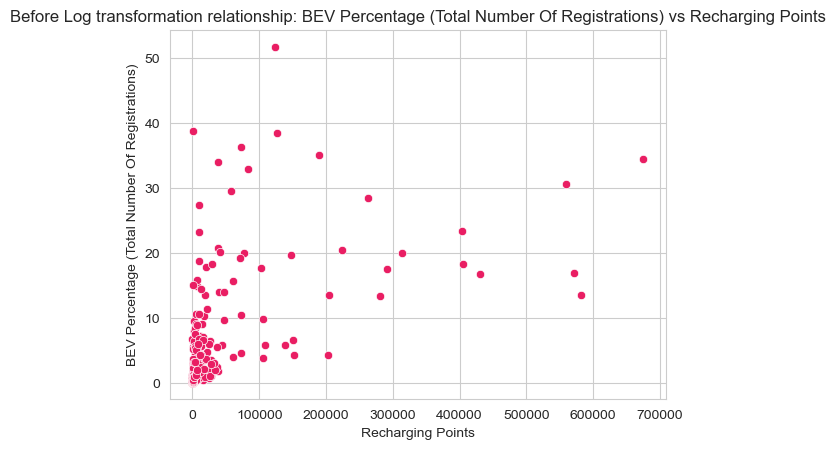

In [49]:
sns.scatterplot(x=dataset['Recharging Points'], y=dataset['BEV Percentage (Total Number Of Registrations)'], color='#E91E63')
plt.title("Before Log transformation relationship: BEV Percentage (Total Number Of Registrations) vs Recharging Points")
plt.savefig("Before Log Transformation_BEV Market Share vs Recharging Points.pdf", format="pdf", bbox_inches="tight")
plt.show()

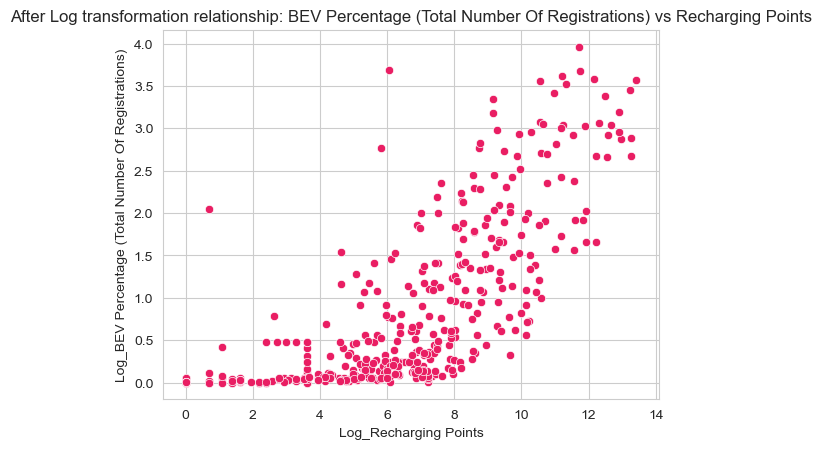

In [50]:
sns.scatterplot(x=dataset['Log_Recharging Points'], y=dataset['Log_BEV Percentage (Total Number Of Registrations)'], color='#E91E63')
plt.title("After Log transformation relationship: BEV Percentage (Total Number Of Registrations) vs Recharging Points")
plt.savefig("After Log Transformation_BEV Market Share vs Recharging Points.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Save the dataset

In [51]:
# Save the full clean dataset
dataset.to_csv(r"C:\Users\Disha\TU Braunschweig\Thesis\Data\Cleaned Dataset.csv", index=False)